In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


import pandas as pd
import numpy as np

import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
df = pd.read_csv('BitcoinHeistData4.csv')
df.dropna()


,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017.0,11.0,18.0,8.333333e-03,1.0,0.0,2.0,1.000500e+08,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016.0,132.0,44.0,2.441410e-04,1.0,0.0,1.0,1.000000e+08,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016.0,246.0,0.0,1.000000e+00,1.0,0.0,2.0,2.000000e+08,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016.0,322.0,72.0,3.906250e-03,1.0,0.0,2.0,7.120000e+07,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016.0,238.0,144.0,7.284841e-02,456.0,0.0,1.0,2.000000e+08,princetonLocky
5,112AmFATxzhuSpvtz1hfpa3Zrw3BG276pc,2016.0,96.0,144.0,8.461400e-02,2821.0,0.0,1.0,5.000000e+07,princetonLocky
6,112E91jxS2qrQY1z78LPWUWrLVFGqbYPQ1,2016.0,225.0,142.0,2.088519e-03,881.0,0.0,2.0,1.000000e+08,princetonCerber
7,112eFykaD53KEkKeYW9KW8eWebZYSbt2f5,2016.0,324.0,78.0,3.906250e-03,1.0,0.0,2.0,1.009900e+08,princetonCerber
8,112FTiRdJjMrNgEtd4fvdoq3TC33Ah5Dep,2016.0,298.0,144.0,2.302828e+00,4220.0,0.0,2.0,8.000000e+07,princetonCerber
9,112GocBgFSnaote6krx828qaockFraD8mp,2016.0,62.0,112.0,3.730000e-09,1.0,0.0,1.0,5.000000e+07,princetonLocky


In [ ]:
df.head()

,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017.0,11.0,18.0,0.008333,1.0,0.0,2.0,100050000.0,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016.0,132.0,44.0,0.000244,1.0,0.0,1.0,100000000.0,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016.0,246.0,0.0,1.000000,1.0,0.0,2.0,200000000.0,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016.0,322.0,72.0,0.003906,1.0,0.0,2.0,71200000.0,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016.0,238.0,144.0,0.072848,456.0,0.0,1.0,200000000.0,princetonLocky


In [ ]:
df.tail()

,address,year,day,length,weight,count,looped,neighbors,income,label
928014,1Be6LrNcMuRwjCvtSpRpUE7ixjUMaudR8r,2013.0,283.0,2.0,1.000,3.0,0.0,1.0,468188946.0,white
928015,1BT461MUnnDaw1cm6Rzf5RVEZk1AtHfChu,2013.0,283.0,6.0,0.125,1.0,0.0,2.0,356652017.0,white
928016,1MhTHRXC7LB6yswn6R5QiaRf5SbiC2AnKj,2013.0,283.0,2.0,0.025,1.0,0.0,1.0,263000000.0,white
928017,1CMRxDPJbaVwbL94SUki4af8Np76TwfAgc,2013.0,283.0,4.0,0.250,1.0,0.0,1.0,143594153.0,white
928018,12ngz7ZqQAuLtCKhwYDqUj1Ewo2HZqcrnx,2013.0,283.0,12.0,0.010,3.0,0.0,1.0,298100000.0,white


In [ ]:
df.size

9280190

In [ ]:
df.shape

(928019, 10)

In [ ]:
df.columns

Index(['address', 'year', 'day', 'length', 'weight', 'count', 'looped',
       'neighbors', 'income', 'label'],
      dtype='object')

In [ ]:
df['label'].unique()

array(['princetonCerber', 'princetonLocky', 'montrealCryptoLocker',
       'montrealCryptXXX', 'paduaCryptoWall', 'montrealWannaCry',
       'montrealDMALockerv3', 'montrealCryptoTorLocker2015',
       'montrealSamSam', 'montrealFlyper', 'montrealNoobCrypt',
       'montrealDMALocker', 'montrealGlobe', 'montrealEDA2',
       'paduaKeRanger', 'montrealVenusLocker', 'montrealXTPLocker',
       'paduaJigsaw', 'montrealGlobev3', 'montrealJigSaw',
       'montrealXLockerv5.0', 'montrealXLocker', 'montrealRazy',
       'montrealCryptConsole', 'montrealGlobeImposter', 'montrealSam',
       'montrealComradeCircle', 'montrealAPT', 'white'], dtype=object)

In [ ]:
df.dtypes

address       object
year         float64
day          float64
length       float64
weight       float64
count        float64
looped       float64
neighbors    float64
income       float64
label         object
dtype: object

In [ ]:
df['label'].value_counts()

white                          886606
paduaCryptoWall                 12390
montrealCryptoLocker             9315
princetonCerber                  9223
princetonLocky                   6625
montrealCryptXXX                 2419
montrealNoobCrypt                 483
montrealDMALockerv3               354
montrealDMALocker                 251
montrealSamSam                     62
montrealGlobeImposter              55
montrealCryptoTorLocker2015        55
montrealGlobev3                    34
montrealGlobe                      32
montrealWannaCry                   28
montrealRazy                       13
montrealAPT                        11
paduaKeRanger                      10
montrealFlyper                      9
montrealXTPLocker                   8
montrealCryptConsole                7
montrealXLockerv5.0                 7
montrealVenusLocker                 7
montrealEDA2                        6
montrealJigSaw                      4
paduaJigsaw                         2
montrealSam 

<AxesSubplot:>

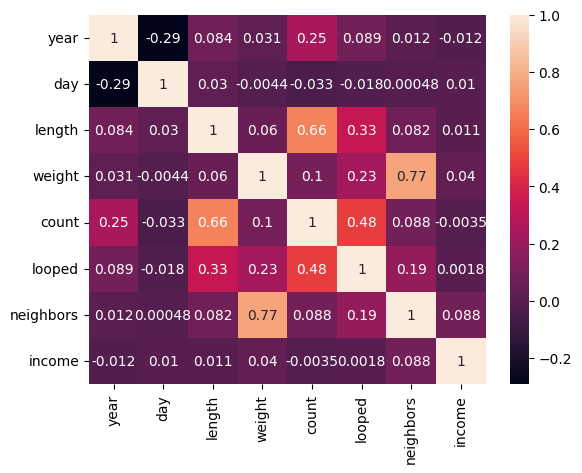

In [ ]:
sns.heatmap(df.corr(),annot=True)

In [ ]:
X = df[['year', 'day', 'length', 'weight', 'count', 'looped', 'neighbors', 'income']]
y = df['label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'X' is not defined

In [ ]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)


Accuracy: 0.9953341522812008


In [ ]:
import joblib

# Save the trained model
joblib.dump(clf, "model.pkl")
print("Model saved as model.pkl")


In [ ]:
import joblib
model = joblib.load("model.pkl")

# Predict on TEST set (not training set)
y_pred = model.predict(X_test)

# Proper evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))


Predicted label: ['white' 'white' 'white' ... 'white' 'white' 'white']


,year,day,length,weight,count,looped,neighbors,income
352554,2012.0,14.0,0.0,0.500000,1.0,0.0,1.0,4.436365e+08
580196,2012.0,242.0,30.0,0.000061,1.0,0.0,1.0,1.013111e+08
729611,2013.0,26.0,144.0,0.000184,2288.0,0.0,2.0,3.488000e+07
93963,2011.0,120.0,4.0,0.125000,1.0,0.0,2.0,2.190000e+09
245824,2011.0,272.0,28.0,0.000488,7.0,0.0,1.0,1.050014e+08
382348,2012.0,44.0,0.0,0.500000,1.0,0.0,2.0,4.650000e+09
863362,2013.0,160.0,6.0,0.125000,1.0,0.0,2.0,3.270000e+08
580412,2012.0,242.0,144.0,52.243437,1593.0,1593.0,269.0,3.897238e+10
516073,2012.0,177.0,16.0,0.295677,65.0,0.0,2.0,2.120000e+09
385768,2012.0,47.0,4.0,0.375000,2.0,2.0,1.0,1.820000e+10
